## Imports and Load Data

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import poisson
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
okc_data = pd.read_csv('../data/raw/okc_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')
sas_data = pd.read_csv('../data/raw/sas_2526.csv', index_col='GAME_DATE', parse_dates=True).drop(columns=['Unnamed: 0'], errors='ignore')

## Weighted Ratings

In [35]:
def weighted_mean(df, is_home, col):
    season = df.loc[(df['IS_HOME'] == is_home) & (~df['PLAYOFF']), col]
    playoff = df.loc[(df['IS_HOME'] == is_home) & (df['PLAYOFF']), col]
    
    n_season = len(season)
    n_playoff = len(playoff)
    
    total = n_season + n_playoff
    if total == 0:
        return np.nan, 0, 0
    return (season.sum() + playoff.sum()) / total, n_season, n_playoff    

In [36]:
def build_ratings(df):
    ratings = {}
    for location, is_home in [('home', True), ('away', False)]:
        off, n_rs, n_po = weighted_mean(df, is_home, 'PTS')
        def_, _,    _   = weighted_mean(df, is_home, 'POINTS_AGAINST')
        ratings[f'{location}_offense'] = off
        ratings[f'{location}_defense'] = def_
        ratings[f'{location}_n_season']    = n_rs
        ratings[f'{location}_n_playoff']    = n_po
    return ratings

In [37]:
okc_ratings = build_ratings(okc_data)
sas_ratings = build_ratings(sas_data)

print(okc_avg)

{'home_offense': np.float64(118.95652173913044), 'home_defense': np.float64(106.76086956521739), 'home_n_season': 41, 'home_n_playoff': 5, 'away_offense': np.float64(119.4), 'away_defense': np.float64(108.75555555555556), 'away_n_season': 41, 'away_n_playoff': 4}


In [38]:
# Ratings summary table
summary = pd.DataFrame({
    'Rating': [
        'Home Offense', 'Home Defense Allowed',
        'Away Offense', 'Away Defense Allowed',
        'Home Games (RS)', 'Home Games (PO)',
        'Away Games (RS)', 'Away Games (PO)',
    ],
    'OKC': [
        f"{okc_ratings['home_offense']:.1f}", f"{okc_ratings['home_defense']:.1f}",
        f"{okc_ratings['away_offense']:.1f}", f"{okc_ratings['away_defense']:.1f}",
        okc_ratings['home_n_season'], okc_ratings['home_n_playoff'],
        okc_ratings['away_n_season'], okc_ratings['away_n_playoff'],
    ],
    'SAS': [
        f"{sas_ratings['home_offense']:.1f}", f"{sas_ratings['home_defense']:.1f}",
        f"{sas_ratings['away_offense']:.1f}", f"{sas_ratings['away_defense']:.1f}",
        sas_ratings['home_n_season'], sas_ratings['home_n_playoff'],
        sas_ratings['away_n_season'], sas_ratings['away_n_playoff'],
    ]
})
print(summary.to_string(index=False))

              Rating   OKC   SAS
        Home Offense 119.0 119.8
Home Defense Allowed 106.9 110.2
        Away Offense 119.4 119.1
Away Defense Allowed 108.8 111.0
     Home Games (RS)    41    40
     Home Games (PO)     6     6
     Away Games (RS)    41    42
     Away Games (PO)     4     7


## Expected Points
$\lambda$ = average of team's own location-split offense and opponent's location-split defense allowed

In [39]:
def expected_points(home_ratings, away_ratings):
    lam_home = (home_ratings['home_offense'] + away_ratings['away_defense']) / 2
    lam_away = (away_ratings['away_offense'] + home_ratings['home_defense']) / 2
    return lam_home, lam_away

LAM_OKC_HOME, LAM_SAS_AWAY = expected_points(okc_ratings, sas_ratings)
LAM_SAS_HOME, LAM_OKC_AWAY = expected_points(sas_ratings, okc_ratings)

print("When OKC is home:")
print(f"  λ OKC: {LAM_OKC_HOME:.2f}  |  λ SAS: {LAM_SAS_AWAY:.2f}")
print("\nWhen SAS is home:")
print(f"  λ OKC: {LAM_OKC_AWAY:.2f}  |  λ SAS: {LAM_SAS_HOME:.2f}")

When OKC is home:
  λ OKC: 115.00  |  λ SAS: 113.01

When SAS is home:
  λ OKC: 114.82  |  λ SAS: 114.27


## Game and Series Simulation

In [40]:
def simulate_game(okc_is_home, rng):
    """
    Draw Poisson scores for one game. Re-draws on ties (impossible in NBA,
    but Poisson is discrete so ties have non-zero probability).
    Returns (okc_pts, sas_pts).
    """
    lam_okc = LAM_OKC_HOME   if okc_is_home else LAM_OKC_AWAY_G
    lam_sas = LAM_SAS_AWAY_G if okc_is_home else LAM_SAS_HOME

    while True:
        okc_pts = rng.poisson(lam_okc)
        sas_pts = rng.poisson(lam_sas)
        if okc_pts != sas_pts:
            return okc_pts, sas_pts

In [41]:
HOME_SCHEDULE = [ False, False, True, False, True]

def simulate_series(rng):
    okc_wins = sas_wins = 1
    winner ="OKC"
    for game_idx, okc_is_home in enumerate(HOME_SCHEDULE):
        okc_pts, sas_pts = simulate_game(okc_is_home, rng)
        
        if okc_pts > sas_pts:
            okc_wins +=1
        else:
            sas_wins +=1
        
        if okc_wins == 4 or sas_wins == 4:
            winner = 'OKC' if okc_wins == 4 else 'SAS'
            break
    return winner, okc_wins, sas_wins, game_idx + 1

## Monte Carlo Simulation

In [42]:
N_SIMS = 10000
rng = np.random.default_rng(42)

results = []

for _ in range(N_SIMS):
    winner, okc_w, sas_w, n_games = simulate_series(rng)
    results.append({
        'winner':       winner,
        'okc_wins':     okc_w,
        'sas_wins':     sas_w,
        'games_played': n_games,
        'outcome':      f"{winner} {max(okc_w, sas_w)}-{min(okc_w, sas_w)}"
    })

results_df = pd.DataFrame(results)

In [45]:
okc_pct = (results_df['winner'] == 'OKC').mean()

print("=== Series Win Probability ===")
print(f"  OKC Thunder : {okc_pct:.1%}")
print(f"  SAS Spurs   : {1 - okc_pct:.1%}")

print("\n=== Series Length ===")
for n, cnt in results_df['games_played'].value_counts().sort_index().items():
    print(f"  {n+2} games: {cnt / N_SIMS:.1%}")

print("\n=== Outcome Breakdown ===")
for outcome, cnt in results_df['outcome'].value_counts().sort_index().items():
    print(f"  {outcome}: {cnt / N_SIMS:.1%}")

=== Series Win Probability ===
  OKC Thunder : 54.9%
  SAS Spurs   : 45.1%

=== Series Length ===
  5 games: 24.7%
  6 games: 37.8%
  7 games: 37.5%

=== Outcome Breakdown ===
  OKC 4-1: 14.4%
  OKC 4-2: 19.8%
  OKC 4-3: 20.7%
  SAS 4-1: 10.3%
  SAS 4-2: 18.0%
  SAS 4-3: 16.8%


## Visualization

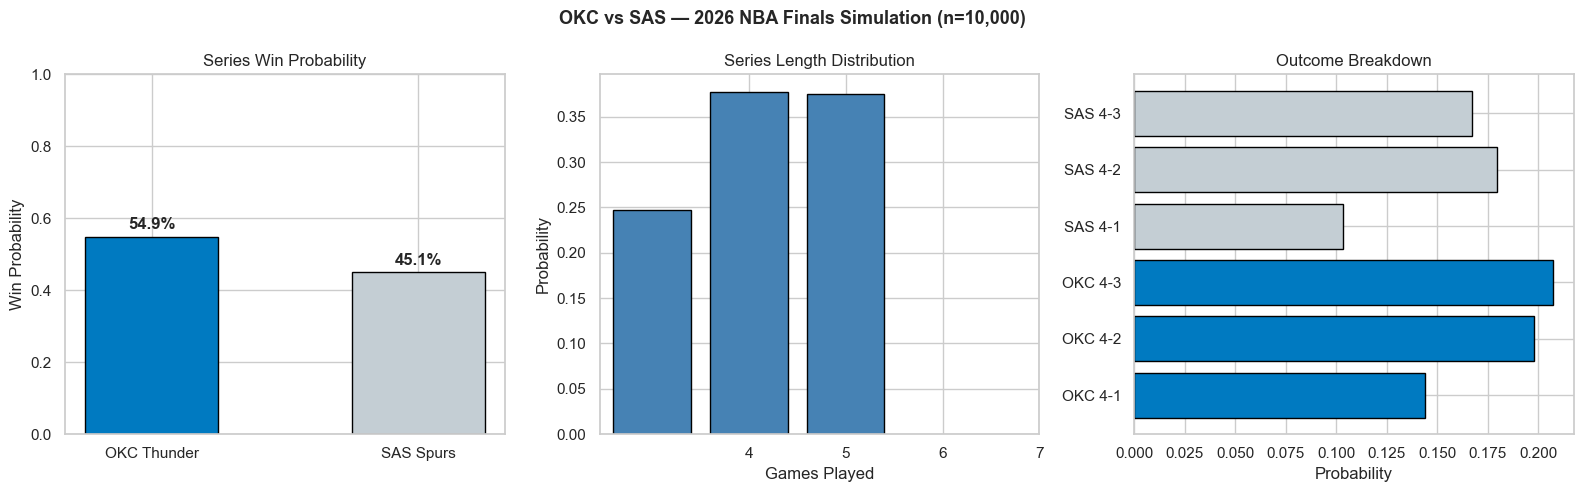

In [46]:
sns.set_theme(style='whitegrid')
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('OKC vs SAS — 2026 NBA Finals Simulation (n=10,000)', fontsize=13, fontweight='bold')

# --- Plot 1: Win probability ---
ax = axes[0]
teams  = ['OKC Thunder', 'SAS Spurs']
probs  = [okc_pct, 1 - okc_pct]
colors = ['#007AC1', '#C4CED4']
bars   = ax.bar(teams, probs, color=colors, edgecolor='black', width=0.5)
ax.set_ylim(0, 1)
ax.set_ylabel('Win Probability')
ax.set_title('Series Win Probability')
for bar, p in zip(bars, probs):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f'{p:.1%}', ha='center', fontweight='bold', fontsize=12)

# --- Plot 2: Series length ---
ax = axes[1]
length_dist = results_df['games_played'].value_counts().sort_index()
ax.bar(length_dist.index, length_dist.values / N_SIMS,
       color='steelblue', edgecolor='black')
ax.set_xticks([4, 5, 6, 7])
ax.set_xlabel('Games Played')
ax.set_ylabel('Probability')
ax.set_title('Series Length Distribution')

# --- Plot 3: Outcome breakdown ---
ax = axes[2]
outcome_counts = results_df['outcome'].value_counts().sort_index()
bar_colors = ['#007AC1' if o.startswith('OKC') else '#C4CED4'
              for o in outcome_counts.index]
ax.barh(outcome_counts.index, outcome_counts.values / N_SIMS,
        color=bar_colors, edgecolor='black')
ax.set_xlabel('Probability')
ax.set_title('Outcome Breakdown')

plt.tight_layout()
plt.savefig('../outputs/series_prediction.png', dpi=150, bbox_inches='tight')
plt.show()